# E-commerce Profitability & Customer Segmentation Analysis

**Tools:** Python, Pandas, Matplotlib, Seaborn

This notebook analyzes an order-level e-commerce dataset (~15,000 orders, 2,000 customers) to answer:
1. Which product categories have the highest / lowest profit margins?
2. How do customers segment using RFM (Recency, Frequency, Monetary) analysis?
3. Which segment drives the most revenue vs. order count?
4. How does category-wise average order value relate to margin?
5. What does the monthly revenue/profit trend look like?


## 1. Setup & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 120

df = pd.read_csv("../data/ecommerce_orders.csv", parse_dates=["order_date"])
print(f"{len(df):,} orders | {df['customer_id'].nunique():,} unique customers")
print(f"Date range: {df['order_date'].min().date()} to {df['order_date'].max().date()}")
df.head()

15,106 orders | 2,000 unique customers
Date range: 2024-01-01 to 2025-12-31


    order_id customer_id order_date  ... total_revenue  profit  profit_margin_pct
0  ORD008679   CUST01125 2024-01-01  ...       2910.04  778.11              26.74
1  ORD005576   CUST00729 2024-01-01  ...       1622.44  111.96               6.90
2  ORD011400   CUST01487 2024-01-01  ...       2937.15  862.92              29.38
3  ORD014184   CUST01862 2024-01-01  ...        302.20  146.24              48.39
4  ORD002460   CUST00321 2024-01-01  ...       2257.29  486.21              21.54

[5 rows x 12 columns]

## 2. Category-wise Profit Margin Analysis

In [2]:
cat_summary = (
    df.groupby("product_category")
    .agg(total_revenue=("total_revenue", "sum"),
         total_profit=("profit", "sum"),
         orders=("order_id", "count"),
         avg_order_value=("total_revenue", "mean"))
    .reset_index()
)
cat_summary["profit_margin_pct"] = (cat_summary["total_profit"] / cat_summary["total_revenue"] * 100).round(2)
cat_summary = cat_summary.sort_values("profit_margin_pct", ascending=False)

overall_margin = df["profit"].sum() / df["total_revenue"].sum() * 100
print(f"Blended overall margin: {overall_margin:.2f}%")
cat_summary

Blended overall margin: 18.20%


  product_category  total_revenue  ...  avg_order_value  profit_margin_pct
1           Beauty     3035057.08  ...      1679.611002              44.24
0          Apparel     7632822.38  ...      2534.137576              39.21
4   Home & Kitchen    10280706.97  ...      4158.862043              27.20
5           Sports     5268479.86  ...      3457.007782              25.14
2      Electronics    68054090.33  ...     20741.874529              13.02
3        Groceries     1996626.94  ...       663.331209              10.06

[6 rows x 6 columns]

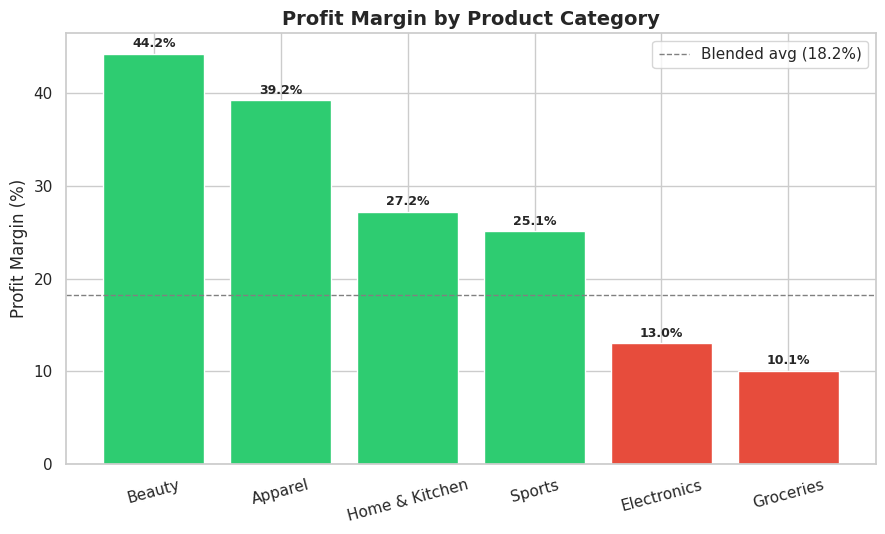

In [3]:
fig, ax = plt.subplots(figsize=(9, 5.5))
colors = ["#2ecc71" if v > overall_margin else "#e74c3c" for v in cat_summary["profit_margin_pct"]]
bars = ax.bar(cat_summary["product_category"], cat_summary["profit_margin_pct"], color=colors)
ax.axhline(overall_margin, color="grey", linestyle="--", linewidth=1, label=f"Blended avg ({overall_margin:.1f}%)")
for bar, val in zip(bars, cat_summary["profit_margin_pct"]):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.7, f"{val:.1f}%", ha="center", fontsize=9, fontweight="bold")
ax.set_title("Profit Margin by Product Category", fontsize=14, fontweight="bold")
ax.set_ylabel("Profit Margin (%)")
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Finding:** Beauty (~44%) and Apparel (~39%) are the highest-margin categories, while Groceries (~10%) and Electronics (~13%) are the lowest — Electronics has high revenue volume but thin margins, a classic low-margin/high-volume category.

## 3. RFM Customer Segmentation

In [4]:
snapshot_date = df["order_date"].max() + pd.Timedelta(days=1)

rfm = df.groupby("customer_id").agg(
    recency=("order_date", lambda x: (snapshot_date - x.max()).days),
    frequency=("order_id", "count"),
    monetary=("total_revenue", "sum"),
).reset_index()

rfm["R_score"] = pd.qcut(rfm["recency"].rank(method="first"), 4, labels=[4, 3, 2, 1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["M_score"] = pd.qcut(rfm["monetary"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["RFM_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

def segment_customer(row):
    if row["R_score"] >= 3 and row["F_score"] >= 3 and row["M_score"] >= 3:
        return "High-Value"
    elif row["F_score"] == 1 and row["R_score"] <= 2:
        return "Churned"
    elif row["R_score"] <= 2 and row["F_score"] >= 2:
        return "At-Risk"
    elif row["frequency"] == 1 and row["R_score"] >= 3:
        return "New"
    else:
        return "Regular"

rfm["segment"] = rfm.apply(segment_customer, axis=1)
rfm.head()

  customer_id  recency  frequency  ...  M_score  RFM_score     segment
0   CUST00001      415          7  ...        3          7     At-Risk
1   CUST00002        1         17  ...        4         12  High-Value
2   CUST00003        1          6  ...        3         10  High-Value
3   CUST00004       44          4  ...        3          8     Regular
4   CUST00005      183          1  ...        2          5     Churned

[5 rows x 9 columns]

In [5]:
seg_summary = (
    rfm.groupby("segment")
    .agg(customers=("customer_id", "count"), revenue=("monetary", "sum"), orders=("frequency", "sum"))
    .reset_index()
)
seg_summary["pct_customers"] = (seg_summary["customers"] / seg_summary["customers"].sum() * 100).round(1)
seg_summary["pct_revenue"] = (seg_summary["revenue"] / seg_summary["revenue"].sum() * 100).round(1)
seg_summary["pct_orders"] = (seg_summary["orders"] / seg_summary["orders"].sum() * 100).round(1)
seg_summary = seg_summary.sort_values("revenue", ascending=False)
seg_summary

      segment  customers      revenue  ...  pct_customers  pct_revenue  pct_orders
2  High-Value        678  69542107.37  ...           33.9         72.2        70.1
0     At-Risk        583  18207908.60  ...           29.2         18.9        18.8
4     Regular        204   4944388.72  ...           10.2          5.1         7.5
1     Churned        417   2813347.54  ...           20.8          2.9         2.8
3         New        118    760031.33  ...            5.9          0.8         0.8

[5 rows x 7 columns]

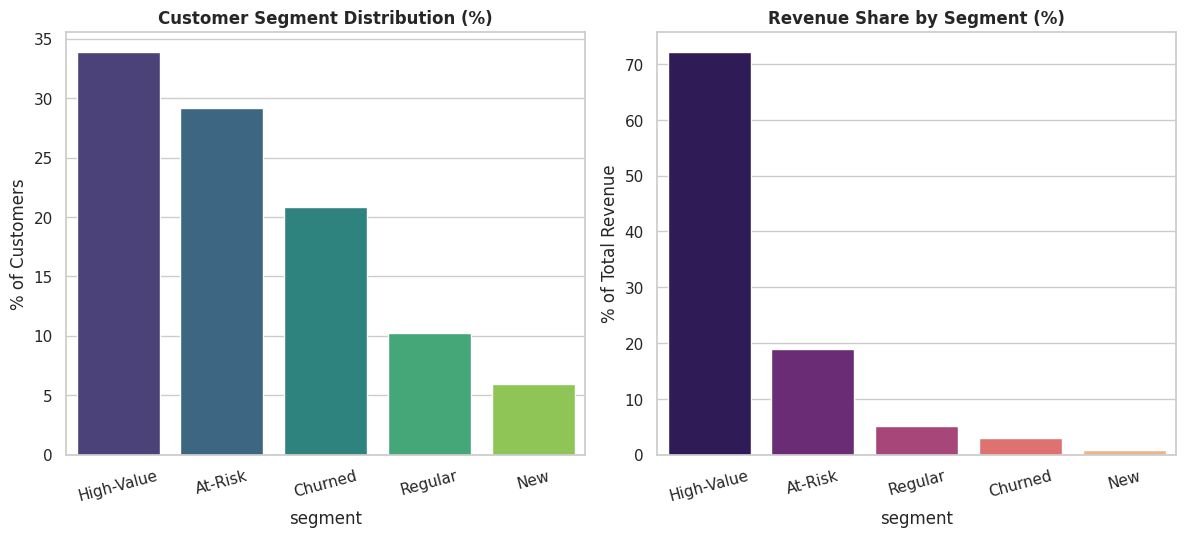

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
seg_order = seg_summary.sort_values("customers", ascending=False)
sns.barplot(data=seg_order, x="segment", y="pct_customers", hue="segment", ax=axes[0], palette="viridis", legend=False)
axes[0].set_title("Customer Segment Distribution (%)", fontweight="bold")
axes[0].set_ylabel("% of Customers")

seg_rev_order = seg_summary.sort_values("revenue", ascending=False)
sns.barplot(data=seg_rev_order, x="segment", y="pct_revenue", hue="segment", ax=axes[1], palette="magma", legend=False)
axes[1].set_title("Revenue Share by Segment (%)", fontweight="bold")
axes[1].set_ylabel("% of Total Revenue")

for ax in axes:
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

**Finding:** The High-Value segment (~34% of customers) drives roughly 72% of total revenue and 70% of order volume — revenue is meaningfully concentrated in repeat, high-spend customers rather than spread evenly.

## 4. Revenue Concentration (Pareto view)

Top 20% of customers generate 58.5% of revenue


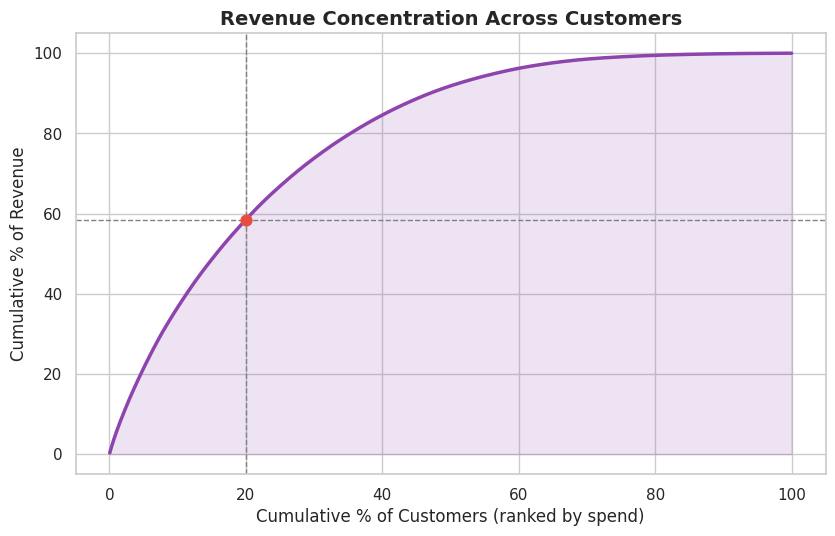

In [7]:
rfm_sorted = rfm.sort_values("monetary", ascending=False).reset_index(drop=True)
rfm_sorted["cum_customers_pct"] = (np.arange(1, len(rfm_sorted)+1) / len(rfm_sorted)) * 100
rfm_sorted["cum_revenue_pct"] = (rfm_sorted["monetary"].cumsum() / rfm_sorted["monetary"].sum()) * 100

top20_idx = (rfm_sorted["cum_customers_pct"] <= 20).sum()
revenue_from_top20 = rfm_sorted.loc[:top20_idx-1, "cum_revenue_pct"].iloc[-1]

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(rfm_sorted["cum_customers_pct"], rfm_sorted["cum_revenue_pct"], color="#8e44ad", linewidth=2.5)
ax.fill_between(rfm_sorted["cum_customers_pct"], rfm_sorted["cum_revenue_pct"], alpha=0.15, color="#8e44ad")
ax.axvline(20, color="grey", linestyle="--", linewidth=1)
ax.axhline(revenue_from_top20, color="grey", linestyle="--", linewidth=1)
ax.scatter([20], [revenue_from_top20], color="#e74c3c", zorder=5, s=60)
ax.set_title("Revenue Concentration Across Customers", fontsize=14, fontweight="bold")
ax.set_xlabel("Cumulative % of Customers (ranked by spend)")
ax.set_ylabel("Cumulative % of Revenue")
plt.tight_layout()
plt.show()

print(f"Top 20% of customers generate {revenue_from_top20:.1f}% of revenue")

## 5. Category-wise AOV vs. Margin

Correlation between AOV and margin: -0.45


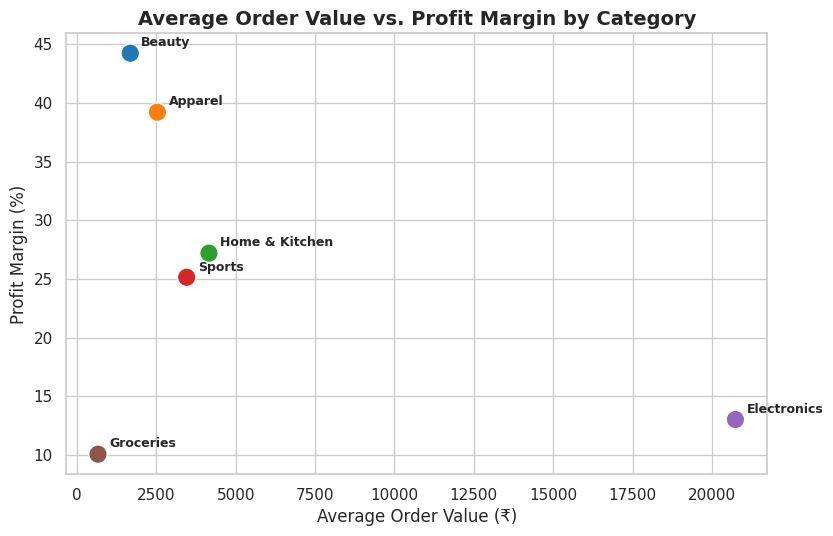

In [8]:
corr = cat_summary["avg_order_value"].corr(cat_summary["profit_margin_pct"])
print(f"Correlation between AOV and margin: {corr:.2f}")

fig, ax = plt.subplots(figsize=(8.5, 5.5))
sns.scatterplot(data=cat_summary, x="avg_order_value", y="profit_margin_pct",
                 s=180, hue="product_category", palette="tab10", ax=ax, legend=False)
for _, row in cat_summary.iterrows():
    ax.annotate(row["product_category"], (row["avg_order_value"], row["profit_margin_pct"]),
                textcoords="offset points", xytext=(8, 5), fontsize=9, fontweight="bold")
ax.set_title("Average Order Value vs. Profit Margin by Category", fontsize=14, fontweight="bold")
ax.set_xlabel("Average Order Value (₹)")
ax.set_ylabel("Profit Margin (%)")
plt.tight_layout()
plt.show()

**Finding:** AOV and margin are negatively correlated across categories — big-ticket categories like Electronics carry high order values but thin margins, while smaller-basket categories like Beauty carry higher margins.

## 6. Monthly Revenue & Profit Trend

Peak month: Dec 2025 with ₹12,973,422 revenue


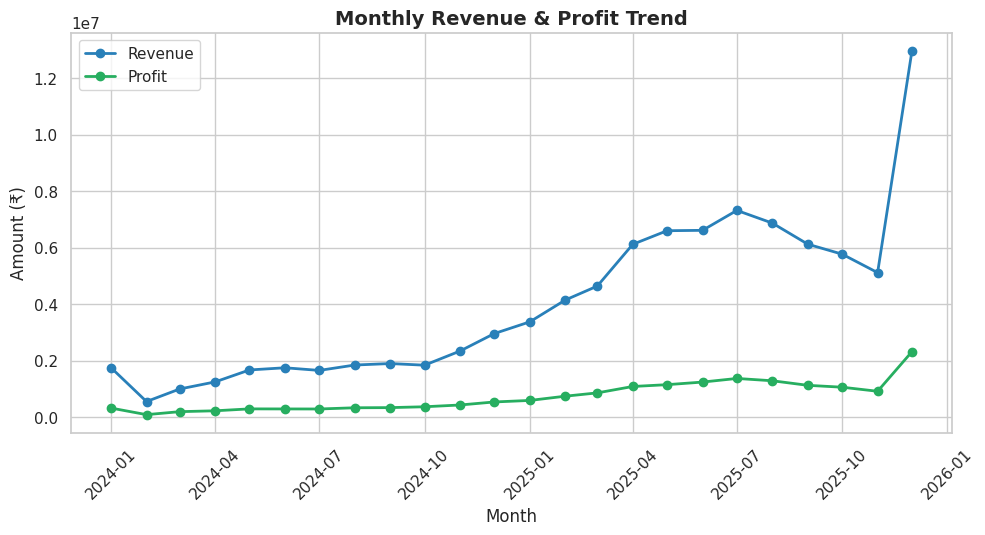

In [9]:
df["order_month"] = df["order_date"].dt.to_period("M").dt.to_timestamp()
monthly = df.groupby("order_month").agg(revenue=("total_revenue", "sum"), profit=("profit", "sum")).reset_index()

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(monthly["order_month"], monthly["revenue"], marker="o", linewidth=2, label="Revenue", color="#2980b9")
ax.plot(monthly["order_month"], monthly["profit"], marker="o", linewidth=2, label="Profit", color="#27ae60")
ax.set_title("Monthly Revenue & Profit Trend", fontsize=14, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Amount (₹)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

best_month = monthly.loc[monthly["revenue"].idxmax()]
print(f"Peak month: {best_month['order_month'].strftime('%b %Y')} with ₹{best_month['revenue']:,.0f} revenue")

**Finding:** Revenue shows a clear seasonal spike around Oct–Dec (festive/holiday shopping season), consistent with typical Indian e-commerce demand patterns.

---
## Summary of Key Findings

| Question | Finding |
|---|---|
| Highest-margin category | Beauty (~44%) |
| Lowest-margin category | Groceries (~10%) |
| High-margin categories (above blended avg) | 4 of 6 categories (~67%) |
| High-Value segment size | ~34% of customers |
| High-Value segment revenue share | ~72% of revenue |
| Revenue concentration | Top 20% of customers = ~59% of revenue |
| AOV vs. margin relationship | Negative correlation (high-ticket ≠ high-margin) |
| Peak season | Oct–Dec (festive season bump) |
